In [32]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
import copy

sys.path.append(os.path.abspath("..")) 

from halo_model.power_spectra.matter_power import MatterPower
from halo_model.config.config import Config
from halo_model.halos.base.profile.profile import CompositeProfile

In [33]:
#import ingredient models


from halo_model.halos.base.clump_mass_func.models.giocoli2010 import ClumpMassGiocoli2010

from halo_model.halos.base.concentration.models.neto2007 import ConcentrationNeto2007
from halo_model.halos.base.concentration.models.pieri2009_clumps import ConcentrationPieri2009_clumps

from halo_model.halos.base.mass_func.models.sheth1999 import MassFuncSheth1999
from halo_model.halos.base.profile.models.nfw import ProfileNFW
from halo_model.halos.base.profile.models.pointmass import ProfilePointMass
from halo_model.halos.base.bias.models.tinker2010 import BiasTinker2010
from halo_model.halos.base.r_vir.models.SO import R_virSO
from halo_model.halos.base.shmr.models.moster2013 import SMHRMoster2013

from halo_model.power_spectra.Pm_computer import Pm_computer

from halo_model.halos.base.mass_converter import NFWMassConverter


In [34]:
cfg = Config()

c_smooth = ConcentrationNeto2007(cfg)
c_clump = ConcentrationPieri2009_clumps(c_smooth, d_vir=0.3)

mass_func = MassFuncSheth1999()

smhr_smooth = SMHRMoster2013(cfg, c_smooth)
smhr_clump = SMHRMoster2013(cfg, c_clump)

smooth_profile = ProfileNFW(c_smooth, R_virSO(cfg))
clump_profile = ProfileNFW(c_clump, R_virSO(cfg))

def w_star(cosmo, M, z):
    return smhr_smooth(cosmo, M, z)
def w_smooth(cosmo, M, z):
    return 1 - w_star(cosmo, M, z)



smooth_profile_wstellar = CompositeProfile(
    smooth_profile, ProfilePointMass(),
    weights=[w_smooth, w_star]
)
clump_profile_wstellar = CompositeProfile(
    clump_profile, ProfilePointMass(),
    weights=[w_smooth, w_star]
)

bias = BiasTinker2010(cfg)

clump_distribution = ProfileNFW(c_smooth, R_virSO(cfg))
clump_mass_func = ClumpMassGiocoli2010(cfg)


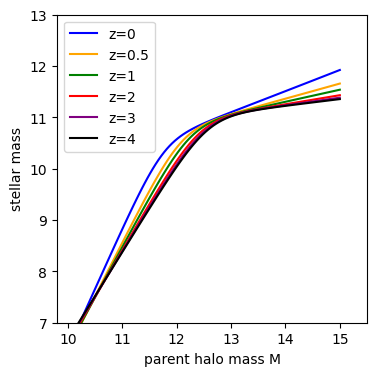

In [35]:
Parent_Halo_masses = np.geomspace(1e10, 1e15, 100)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'black']
plt.figure(figsize=(4,4))
for i, z in enumerate([0, 0.5, 1, 2, 3, 4]):
    logsmhr_vals = [np.log10(Parent_Halo_mass* smhr_smooth(None, Parent_Halo_mass, z)) for Parent_Halo_mass in Parent_Halo_masses]
    plt.plot(np.log10(Parent_Halo_masses), logsmhr_vals,
             color=colors[i], label=f'z={z}')
plt.xlabel("parent halo mass M")
plt.ylabel("stellar mass")
plt.ylim(7, 13)
plt.xlim(9.8, 15.5)
plt.legend()
plt.show()

In [36]:
cfg.M_min, cfg.M_max = 1e6, 1e16
Pm_std = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)

Pm_stellar = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile_wstellar, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile_wstellar, 
                 clump_distribution=clump_distribution)

k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)

Pm_comps_tot = Pm_computer(Pm_std, k_vals)
Pm_stellar_tot = Pm_computer(Pm_stellar, k_vals)

interpolating Ic and Jc functions...
interpolating Ic and Jc functions...


In [40]:
from scipy.optimize import brentq

#compute matter power spectra in different mass bins

M_bins = [
    [1e10, 1e11],
    [1e11, 1e12],
    [1e12, 1e13],
    [1e13, 1e14],
    [1e14, 1e15]
]

# Note that in Debackere they use m500c mass definition, so we must convert the mass bins accordingly:
mass_converter = NFWMassConverter(cfg)

Pm_comps_list = []
Pm_stellar_comps_list = []
for M_bin in M_bins:
    
    def M200m_from_M500c_finder(M500c):
        f = lambda logfrac: (
            mass_converter(
            cfg.massdef, "500c", np.exp(logfrac)*M500c, c_smooth(cfg.cosmo, np.exp(logfrac)*M500c, cfg.z), cfg.z
            ) 
            - M500c
        )
        logfrac = brentq(f, -3, 3)
        M200m = np.exp(logfrac)*M500c
        return M200m
    
    M_min, M_max = M_bin
            
    M_min = M200m_from_M500c_finder(M_min) 
    cfg.M_min = M_min
    
    M_max = M200m_from_M500c_finder(M_max) 
    cfg.M_max = M_max
    
    Pm_std = MatterPower(cfg, 
                 mass_func=mass_func, 
                 smooth_profile=smooth_profile, 
                 bias=bias,
                 clump_mass_func=clump_mass_func, 
                 clump_profile=clump_profile, 
                 clump_distribution=clump_distribution)
        
    Pm_stellar = MatterPower(cfg, 
                    mass_func=mass_func, 
                    smooth_profile=smooth_profile_wstellar, 
                    bias=bias,
                    clump_mass_func=clump_mass_func, 
                    clump_profile=clump_profile_wstellar, 
                    clump_distribution=clump_distribution)

    k_vals = np.logspace(np.log10(cfg.k_min), np.log10(cfg.k_max), cfg.N_k)
    Pm_comps = Pm_computer(Pm_std, k_vals)
    Pm_comps_list.append(Pm_comps)
    Pm_stellar = Pm_computer(Pm_stellar, k_vals)
    Pm_stellar_comps_list.append(Pm_stellar)

interpolating Ic and Jc functions...


interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...
interpolating Ic and Jc functions...


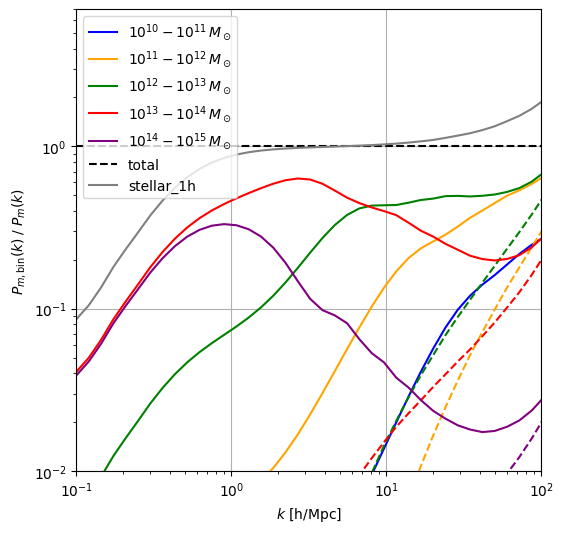

In [41]:
plt.figure(figsize=(6, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, Pm_comps in enumerate(Pm_comps_list):
    Pm_stellar_comps = Pm_stellar_comps_list[i]
    M_min, M_max = M_bins[i]

    exp_min = int(np.log10(M_min))
    exp_max = int(np.log10(M_max))
    label = rf'$10^{{{exp_min}}} - 10^{{{exp_max}}}\,M_\odot$'
    plt.plot(k_vals, Pm_stellar_comps['P_1h']/Pm_comps_tot['P_tot'], label = label, linestyle='-', color=colors[i])
    plt.plot(k_vals, (Pm_stellar_comps['P_1h'] - Pm_comps['P_1h'])/Pm_comps_tot['P_tot'], linestyle='--', color=colors[i])
    # plt.plot(k_vals, Pm_stellar_comps['P_1h']/Pm_comps_tot['P_1h'], linestyle=':', color=colors[i])


Pm_stellar_tot_1h = np.zeros_like(Pm_stellar_comps_list[0]['P_1h'])
for i, Pm_stellar_comps in enumerate(Pm_stellar_comps_list):
    Pm_stellar_tot_1h += np.array(Pm_stellar_comps['P_1h'])

plt.plot(k_vals, Pm_comps_tot['P_tot']/Pm_comps_tot['P_tot'], label = f'total', linestyle='--', color='black')
plt.plot(k_vals, Pm_stellar_tot_1h/Pm_comps_tot['P_tot'], label = f'stellar_1h', linestyle='-', color='grey')
plt.yscale('log')
plt.xscale('log')

# plt.ylim(1e-3, 1e1)
# plt.xlim(np.min(k_vals), np.max(k_vals))
plt.ylim(1e-2, 7)
plt.xlim(1e-1, 1e2)

plt.xlabel(r'$k$ [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{bin}}(k) \; / \; P_m(k)$')

plt.grid()
plt.legend()

plt.xlim()

plt.savefig("plots_Pm_stellar_contributions/Pm_1h_massbin_ratios.pdf")
plt.show()

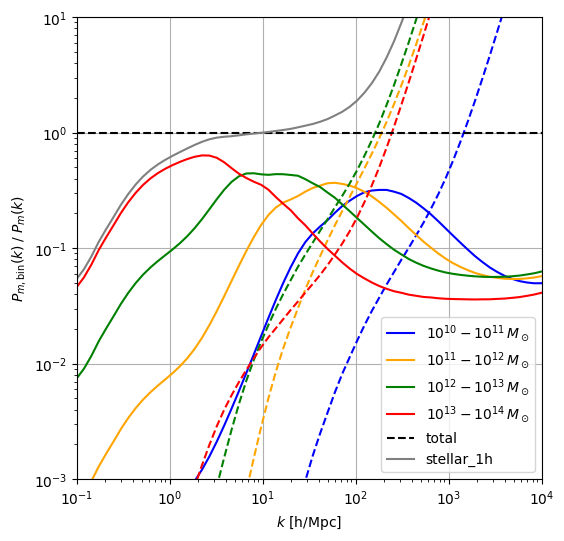

In [ ]:
plt.figure(figsize=(6, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, Pm_comps in enumerate(Pm_comps_list[:-1]):
    Pm_stellar_comps = Pm_stellar_comps_list[i]
    M_min, M_max = M_bins[i]

    exp_min = int(np.log10(M_min))
    exp_max = int(np.log10(M_max))
    label = rf'$10^{{{exp_min}}} - 10^{{{exp_max}}}\,M_\odot$'
    plt.plot(k_vals, Pm_comps['P_1h']/Pm_comps_tot['P_tot'], label = label, linestyle='-', color=colors[i])
    plt.plot(k_vals, (Pm_stellar_comps['P_1h'] - Pm_comps['P_1h'])/Pm_comps_tot['P_tot'], linestyle='--', color=colors[i])
    # plt.plot(k_vals, Pm_stellar_comps['P_1h']/Pm_comps_tot['P_1h'], linestyle=':', color=colors[i])


Pm_stellar_tot_1h = np.zeros_like(Pm_stellar_comps_list[0]['P_1h'])
for i, Pm_stellar_comps in enumerate(Pm_stellar_comps_list[:-1]):
    Pm_stellar_tot_1h += np.array(Pm_stellar_comps['P_1h'])

plt.plot(k_vals, Pm_comps_tot['P_tot']/Pm_comps_tot['P_tot'], label = f'total', linestyle='--', color='black')
plt.plot(k_vals, Pm_stellar_tot_1h/Pm_comps_tot['P_tot'], label = f'stellar_1h', linestyle='-', color='grey')
plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-3, 1e1)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel(r'$k$ [h/Mpc]')
plt.ylabel(r'$P_{m, \mathrm{bin}}(k) \; / \; P_m(k)$')

plt.grid()
plt.legend()

plt.xlim()

plt.savefig("plots_Pm_stellar_contributions/Pm_1h_massbin_ratios.pdf")
plt.show()

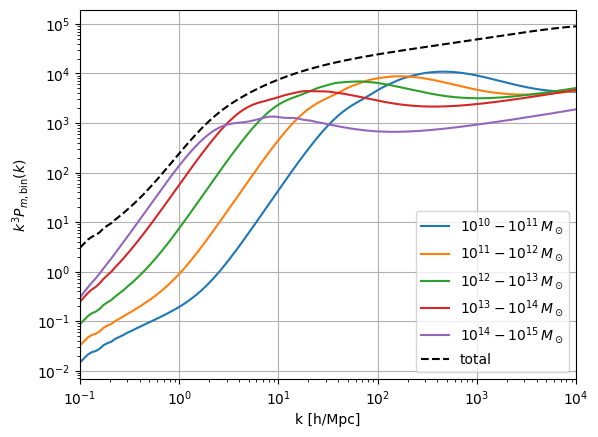

In [ ]:
for i, Pm_comps in enumerate(Pm_comps_list):
    M_min, M_max = M_bins[i]
    exp_min = int(np.log10(M_min))
    exp_max = int(np.log10(M_max))
    label = rf'$10^{{{exp_min}}} - 10^{{{exp_max}}}\,M_\odot$'
    plt.plot(k_vals, k_vals**3 *Pm_comps['P_tot'], label = label, linestyle='-')
    
plt.plot(k_vals, k_vals**3 *Pm_comps_tot['P_tot'], label = f'total', linestyle='--', color='black')
plt.yscale('log')
plt.xscale('log')

plt.ylim(None, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$ k^3 P_{m, \mathrm{bin}}(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_massbins.pdf")
plt.show()

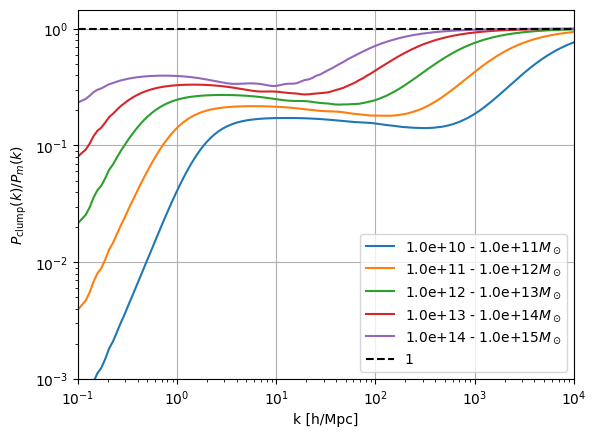

In [ ]:
for i, Pm_comps in enumerate(Pm_comps_list):
    M_min, M_max = M_bins[i]
    clump_contribution = Pm_comps['P_1h_sc'] + Pm_comps['P_1h_cc'] + Pm_comps['P_1h_self_c']
    plt.plot(k_vals, clump_contribution/Pm_comps['P_tot'], label = f'{M_min:.1e} - {M_max:.1e}' + r'$M_\odot$', linestyle='-')
    
plt.plot(k_vals, np.ones_like(k_vals), label = f'1', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-3, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_\mathrm{clump}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()


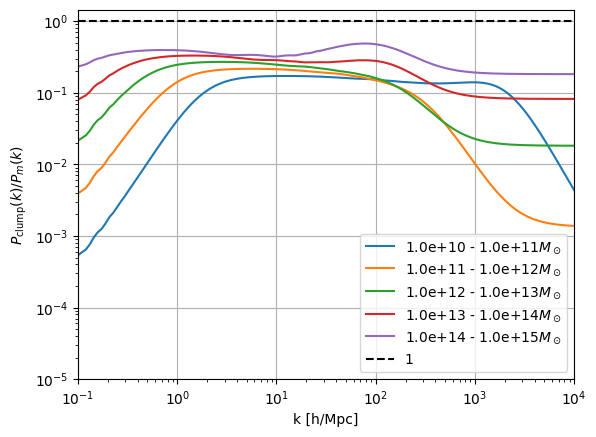

In [ ]:
for i, Pm_stellar_comps in enumerate(Pm_stellar_comps_list):
    M_min, M_max = M_bins[i]
    clump_contribution = Pm_stellar_comps['P_1h_sc'] + Pm_stellar_comps['P_1h_cc'] + Pm_stellar_comps['P_1h_self_c']
    plt.plot(k_vals, clump_contribution/Pm_stellar_comps['P_tot'], label = f'{M_min:.1e} - {M_max:.1e}' + r'$M_\odot$', linestyle='-')
    
plt.plot(k_vals, np.ones_like(k_vals), label = f'1', linestyle='--', color='black')

plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-5, None)
plt.xlim(np.min(k_vals), np.max(k_vals))

plt.xlabel('k [h/Mpc]')
plt.ylabel(r'$P_\mathrm{clump}(k) / P_m(k)$')

plt.grid()
plt.legend()

plt.savefig("plots_Pm_contributions/Pm_1h_ratios.pdf")
plt.show()
